# YUVA Data Science Internship - Task 3
## Unsupervised Learning: K-Means Clustering on Practo Doctor Dataset

In [8]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # Fixes the Windows memory leak warning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("practo_1000_plus_cleaned.csv")

# Select numerical features for clustering
features = ['Experience_in_years', 'Consultation_Fee', 'Patient_Rating', 'Reviews']
X = df[features].dropna().copy()

# Feature Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset scaled successfully. Shape:", X_scaled.shape)

Dataset scaled successfully. Shape: (1313, 4)


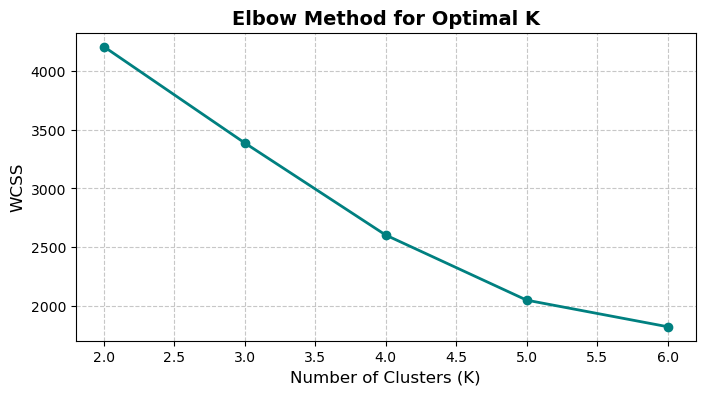

Silhouette Scores: {2: np.float64(0.3235801990824972), 3: np.float64(0.3301694042152616), 4: np.float64(0.35249322656135945), 5: np.float64(0.36636721201085654), 6: np.float64(0.27511234916222604)}


In [11]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)

# Finding optimal K using WCSS and Silhouette Score
wcss = []
sil_scores = {}
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init = 10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores[k] = silhouette_score(X_scaled, labels)

# Plotting Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o', color='teal', linewidth=2)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Silhouette Scores:", sil_scores)

### Observations & Analysis:
* **Elbow Curve Analysis:** The WCSS plot exhibits a steady downward trajectory with an inflection point (elbow) around $K = 4$, indicating diminishing returns in variance reduction beyond four clusters.
* **Silhouette Score Evaluation:** The silhouette scores across evaluated clusters are:
  * **$K = 2$:** $0.3236$
  * **$K = 3$:** $0.3302$
  * **$K = 4$:** $0.3525$ (optimal balance of cluster cohesion and separation)
  * **$K = 5$ & $K = 6$:** Show a drop or degradation in cohesion ($0.2751$ at $K=6$), confirming that $K = 4$ provides the most robust and interpretable segmentation for the practitioner marketplace.

In [12]:
# Fit K-Means with K=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate cluster means
cluster_profile = X.groupby('Cluster').agg(
    Mean_Experience=('Experience_in_years', 'mean'),
    Mean_Fee=('Consultation_Fee', 'mean'),
    Mean_Rating=('Patient_Rating', 'mean'),
    Mean_Reviews=('Reviews', 'mean'),
    Doctor_Count=('Experience_in_years', 'count')
).reset_index()

print("Cluster Profiles:")
display(cluster_profile.style.background_gradient(cmap='Blues'))

Cluster Profiles:


,Cluster,Mean_Experience,Mean_Fee,Mean_Rating,Mean_Reviews,Doctor_Count
0,0,19.195761,686.031172,95.736908,109.750623,802
1,1,24.369128,891.040268,59.979866,9.758389,149
2,2,33.335312,1325.727003,93.821958,107.103858,337
3,3,23.440000,830.000000,96.080000,2323.680000,25


###  Observations & Cluster Profiling Analysis:
* **Cluster 0 (Mainstream Practitioners — 802 Doctors):** 
  * Represents the largest foundational cohort of the marketplace. 
  * Features moderate professional experience ($\approx 19.2$ years), standard consultation fees ($\approx 686$₹), high patient recommendation ratings ($95.7\%$), and steady review volumes ($\approx 110$ reviews).
* **Cluster 1 (Low-Engagement / Lower-Rating Cohort — 149 Doctors):** 
  * Consists of mid-to-senior practitioners ($\approx 24.4$ years experience) with moderate pricing ($\approx 891$₹).
  * Distinctly characterized by a significant drop in patient satisfaction ratings ($\approx 60.0\%$) and very minimal digital feedback volume ($\approx 10$ reviews), indicating potential digital profile optimization gaps.
* **Cluster 2 (Senior / Premium Consultants — 337 Doctors):** 
  * Comprises highly seasoned practitioners ($\approx 33.3$ years experience) who command premium consultation fees ($\approx 1,325$₹).
  * Maintains strong patient recommendation trust ($93.8\%$) alongside healthy, consistent review engagement ($\approx 107$ reviews).
* **Cluster 3 (High-Popularity Elite Specialists — 25 Doctors):** 
  * A small, highly influential elite group with moderate experience ($\approx 23.4$ years) and standard pricing ($\approx 830$₹).
  * Exceptionally distinguished by **massive digital visibility**, averaging over $2,323$ patient reviews while preserving top-tier satisfaction ($96.1\%$).

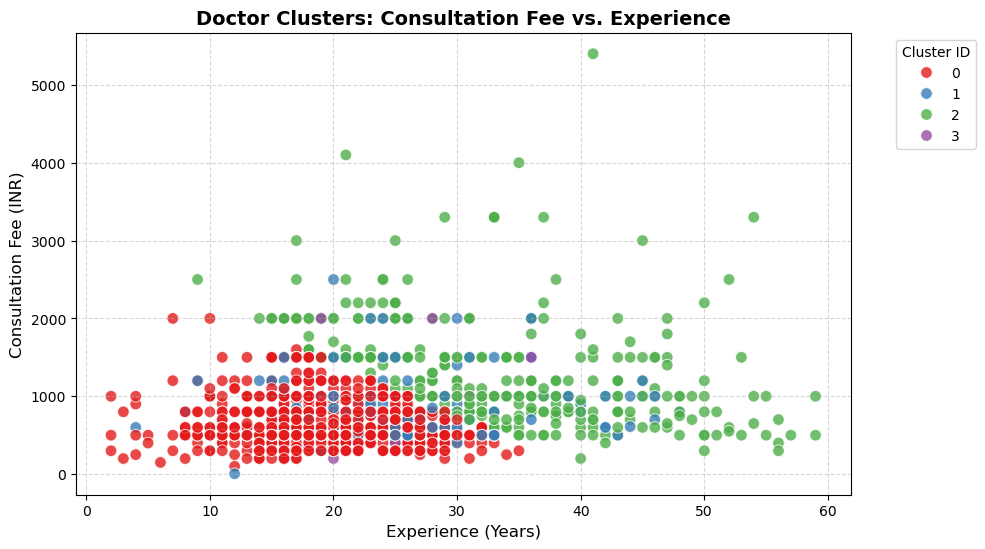

In [13]:
# Scatter plot of Fee vs Experience colored by Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X, 
    x='Experience_in_years', 
    y='Consultation_Fee', 
    hue='Cluster', 
    palette='Set1', 
    s=70, 
    alpha=0.8
)
plt.title('Doctor Clusters: Consultation Fee vs. Experience', fontsize=14, fontweight='bold')
plt.xlabel('Experience (Years)', fontsize=12)
plt.ylabel('Consultation Fee (INR)', fontsize=12)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations & Scatter Plot Analysis:
* **Cluster 0 (Red — Mainstream Practitioners):** Forms the dense core of the dataset, spanning experience levels from $2$ to $35$ years with consultation fees predominantly under ₹1,500. This represents standard, everyday outpatient healthcare delivery.
* **Cluster 1 (Blue — Mid/Senior Tier):** Interspersed across moderate-to-high experience levels (roughly $10$ to $45$ years) with fees generally ranging between ₹500 and ₹2,000, capturing the transitional bridge between standard and senior consulting practices.
* **Cluster 2 (Green — Senior & Premium Outliers):** Covers the widest spread of professional experience (stretching up to nearly $60$ years) and captures the highest fee tiers and pricing outliers (reaching up to ₹5,400), reflecting highly seasoned clinical specialists and premium hospital networks.
* **Cluster 3 (Purple — Niche / Distinct Cohort):** Appears as a compact set of isolated points across specific fee-experience intersections (such as near $20$ years experience at ₹200 and ₹2,000), representing specialized behavioral segments driven heavily by digital review volumes and satisfaction scores rather than simple linear pricing.